In [3]:
%matplotlib inline
import jax.numpy as jnp
import numpy as np
from jax import random

import matplotlib.pyplot as plt

# 1

In [5]:
x = jnp.array([0.0, 1.0, 2.0, 4.0, 5.0])
y = jnp.array([1.0, 0.5, -0.1, -0.9, 1.1])

design_matrix = lambda x: jnp.column_stack([jnp.ones(len(x)), x, x**2, x**3])

Phi = design_matrix(x)

## 1.1

Insert from goodnotes

## 1.2

In [9]:
w_mle = jnp.linalg.inv(Phi.T @ Phi) @ Phi.T @ y

print(np.array2string(w_mle, precision=2))

[ 0.95  0.27 -0.69  0.13]


## 1.3

In [17]:
alpha = 1/2
beta = 25
S = jnp.linalg.inv(alpha * jnp.identity(4) + beta * Phi.T @ Phi)
m = beta * S @ Phi.T @ y

print(np.array2string(m, precision=2))
print(np.array2string(S, precision=2))

[ 0.95  0.25 -0.68  0.13]
[[ 0.04 -0.04  0.01 -0.  ]
 [-0.04  0.13 -0.06  0.01]
 [ 0.01 -0.06  0.04 -0.  ]
 [-0.    0.01 -0.    0.  ]]


## 1.4

In [19]:
phi_star = jnp.array([1, 3, 9, 27])

m_pred = m.T @ phi_star
S_pred = phi_star.T @ S @ phi_star + 1/25

print(np.array2string(m_pred, precision=2))
print(np.array2string(S_pred, precision=2))

-1.
0.07


# 2

## 2.1

# 3

## 3.1

## 3.2

## 3.3

In [21]:
print(jnp.log(2*jnp.pi*jnp.e*(6/5)))

3.0201986


## 3.4

In [22]:
from scipy.stats import norm
interval = norm.interval(0.95, loc = 1/4, scale = jnp.sqrt(6/5))
print(interval)

(np.float64(-1.8970330529897854), np.float64(2.3970330529897854))


# 5

In [1]:
%matplotlib inline
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import seaborn as snb

from scipy.stats import poisson
from scipy.stats import gamma

from exercise9 import compute_effective_sample_size
from exercise9 import compute_Rhat
from exercise9 import plot_summary
from exercise9 import metropolis

# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

# style stuff
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.1)

## 5.1

In [19]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (jnp.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              jnp.array with MCMC samples (jnp.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)

        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as jnp.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas, accepts

In [20]:
def metropolis_multiple_chains(log_target, num_params, num_chains, tau, num_iter, theta_init, seeds, warm_up=0):
    """ Runs multiple Metropolis-Hastings chains. The i'th chain should be initialized using the i'th vector in theta_init, i.e. theta_init[i, :]

    Arguments:
        log_target:         function for evaluating the log joint distribution
        num_params:         number of parameters of the joint distribution (integer)
        num_chains:         number of MCMC chains
        tau:                variance of Gaussian proposal distribution (positive real)
        num_iter:           number of iterations for each chain (integer)
        theta_init:         array of initial values (jnp.array with shape (num_chains, num_params))        
        seeds:              seed for each chain (jnp.array with shape (num_chains))
        warm_up:            number of warm up samples to be discarded
    
    returns:
        thetas              jnp.array of samples from each chain after warmup (shape: num_chains x (num_iter + 1 - warm_up))
        accept_rates        jnp.array of acceptances rate for each chain (shapes: num_chains)
    
     """
    
    # verify dimension of initial parameters 
    assert theta_init.shape == (num_chains, num_params), "theta_init seems to have the wrong dimensions. Plaese check your code."

    ##############################################
    # Your solution goes here
    ##############################################
    
    # prepare arrays for storing samples
    thetas = []
    accept_rates = []    

    # run sampler for each chain
    for idx_chain in range(num_chains):
        print(f'Running chain {idx_chain}. ', end='')
        thetas_temp, accepts_temp = metropolis(log_target, num_params, tau, num_iter, theta_init=theta_init[idx_chain], seed=seeds[idx_chain])
        thetas.append(thetas_temp)
        accept_rates.append(jnp.array(accepts_temp))

    thetas = jnp.stack(thetas, axis=0)
    accept_rates = jnp.stack(accept_rates, axis=0)

    # discard warm-up samples
    thetas = thetas[:, warm_up:, :]
    
    ##############################################
    # End of solution
    ##############################################

    # verify dimensions and return
    assert thetas.shape == (num_chains, num_iter+1-warm_up, num_params), f"The expected shape of chains is ({num_chains}, {num_iter+1-warm_up}, {num_params}) corresponding to (num_chains, num_iter+1-warm_up), but the actual shape is {thetas.shape}. Check your implementation."
    assert len(accept_rates) == num_chains
    return thetas, accept_rates

# mcmc settings
#num_chains = 4
#num_iter = 1000
#proposal_variance = 0.1
#num_params = 1
#warm_up = 0
#seeds = jnp.arange(num_chains)

# generate initial values from N(0, 5)
#key = random.PRNGKey(1)
#theta_init = 5*random.normal(key, shape=(num_chains, num_params))

# sample
#chains, accepts = metropolis_multiple_chains(log_target, num_params, num_chains, proposal_variance, num_iter, theta_init, seeds, warm_up)

# report estimated mean and variance
#print(f'\nEstimated mean:\t\t{jnp.mean(chains.ravel()):+3.2f}')
#print(f'Estimated variance:\t{jnp.var(chains.ravel()):+3.2f}')

In [21]:
log_npdf = lambda x, m, v: -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)

In [22]:
def log_joint(theta):
    x, z = theta
    prior = log_npdf(z, 1, 1)
    likelihood = log_npdf(x, 0, jnp.exp(z))
    return prior + likelihood

In [24]:
theta_init = jnp.array([[-1, 0], [2, 5]])
num_chains = 2
tau = 2
num_iter = 3000
seeds = jnp.arange(num_chains)
num_params = 2
warm_up = 0

chains, accepts = metropolis_multiple_chains(log_joint, num_params, num_chains, tau, num_iter, theta_init, seeds, warm_up)

Running chain 0. Acceptance ratio: 0.35
Running chain 1. Acceptance ratio: 0.35


Estimated Rhat:				1.02
Total number of samples:		6000
Number of effective samples:		254
Relative sample efficiency:		0.042

The true mean is:			-1.00
The estimated mean is:			0.57
The estimated variance is:		2.72
The MCSE for the mean is:		0.10


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

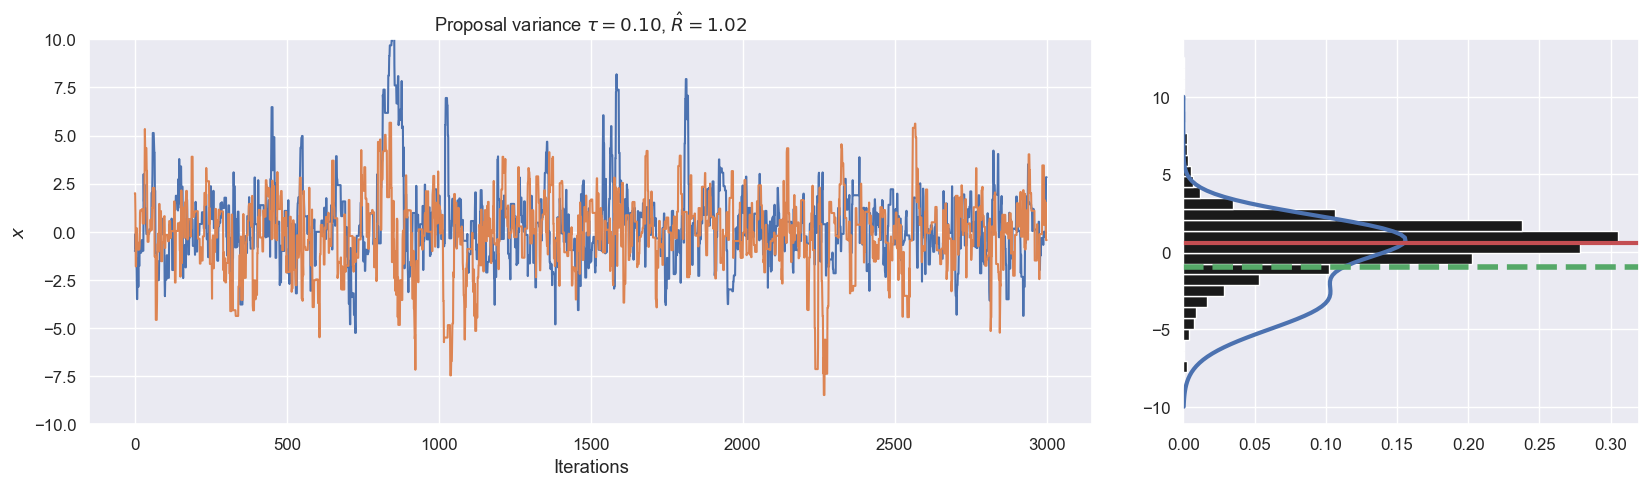

In [25]:
# compute estimate of mean and standard deviation
estimated_mean = jnp.mean(chains.ravel())
estimated_var = jnp.var(chains.ravel())
estimated_std = jnp.sqrt(estimated_var)

# compute \hat{R}-statistics (the function an array of shape (num_chains, num_samples, num_params))
Rhat = compute_Rhat(chains)

# calculate total number of samples across all chains, but excluding warm-up:
total_number_samples = num_chains * (num_iter - warm_up)

# calculate the number of effective samples (the function an array of shape (num_chains, num_samples, num_params))
S_eff = compute_effective_sample_size(chains)

# calculate relative sample efficiency
R_eff = S_eff/total_number_samples

# estimate MC error
MC_error = estimated_std/jnp.sqrt(S_eff)

# print results
print(f'Estimated Rhat:\t\t\t\t{Rhat[0]:3.2f}')
print(f'Total number of samples:\t\t{total_number_samples}')
print(f'Number of effective samples:\t\t{S_eff[0]}')
print(f'Relative sample efficiency:\t\t{R_eff[0]:4.3f}\n')


print(f'The true mean is:\t\t\t{true_mean:3.2f}')
print(f'The estimated mean is:\t\t\t{estimated_mean:3.2f}')
print(f'The estimated variance is:\t\t{estimated_var:3.2f}')
print(f'The MCSE for the mean is:\t\t{MC_error[0]:3.2f}')


# visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
gs = axes[0].get_gridspec()
axes[0].remove()
axes[1].remove()
ax0 = fig.add_subplot(gs[:2])
ax1 = axes[2]
ax0.plot(chains[:, :, 0].T)
ax0.set(xlabel='Iterations', ylabel='$x$', ylim=(x_space[0,0], x_space[-1,0]), title=f'Proposal variance $\\tau = {proposal_variance:3.2f}$, $\\hat{{R}} =  {Rhat[0]:3.2f}$')

ax1.hist(chains.flatten(), 30, density=True, orientation='horizontal', color='k');
ax1.plot(jnp.exp(log_target(x_space)), x_space, linewidth=3, label='Target distribution');
ax1.axhline(true_mean, color='g', linestyle='--', linewidth=4, label='True mean')
ax1.axhline(estimated_mean, color='r', linestyle='-', linewidth=3, label='Estimated mean')
ax1.axhline(estimated_mean+1.96*MC_error, color='r', linestyle='--', linewidth=1, alpha=0.75)
ax1.axhline(estimated_mean-1.96*MC_error, color='r', linestyle='--', linewidth=1, label='95% interval', alpha=0.75)
ax1.set(ylabel='$x$', title='Histogram of all samples')
ax1.legend(loc='upper right');
